# Fig: example infotaxis search with miss

This notebook:
- plots a figure with search behavior with miss
- use miss sequence prototyped in `20251028_fig_infotaxis_prototype_miss.ipynb`

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib

from infotaxis import utils_plot_hex, hex_ops

In [2]:
path_data = Path("../simulations")

path_fig = Path("../figs")

In [3]:
# Load prototype run
ds = xr.open_dataset(path_data / "infotaxis_miss.nc", engine="netcdf4")

In [4]:
# Find pmax across ping
# Will plot only up to pmax across threshold
pmax_th = 0.95
ping_cross_th = ds["d_all"].max(dim="canvas") > pmax_th
ping_cross = np.argwhere(ping_cross_th.values).min()
ping_cross

np.int64(25)

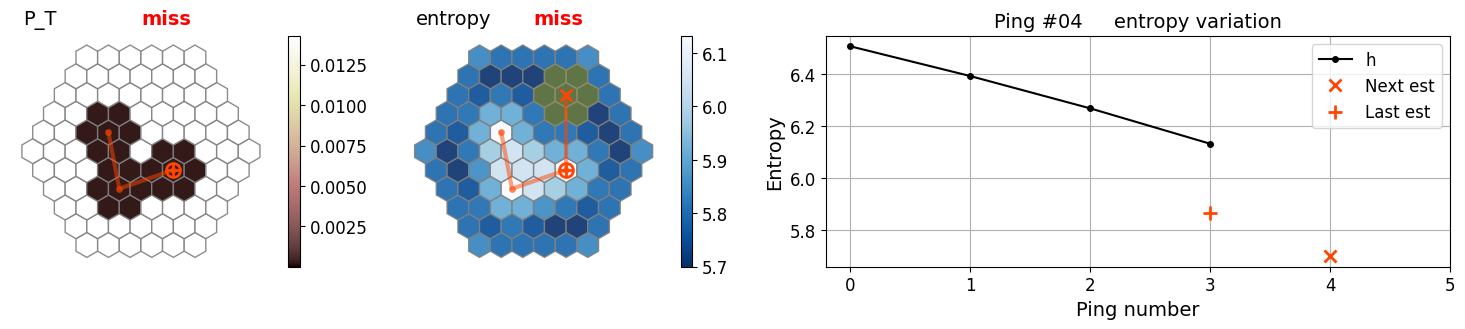

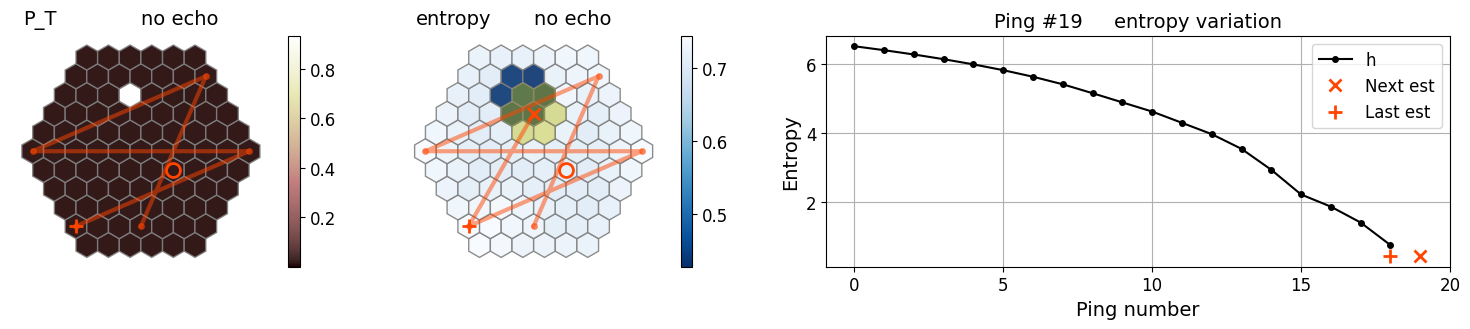

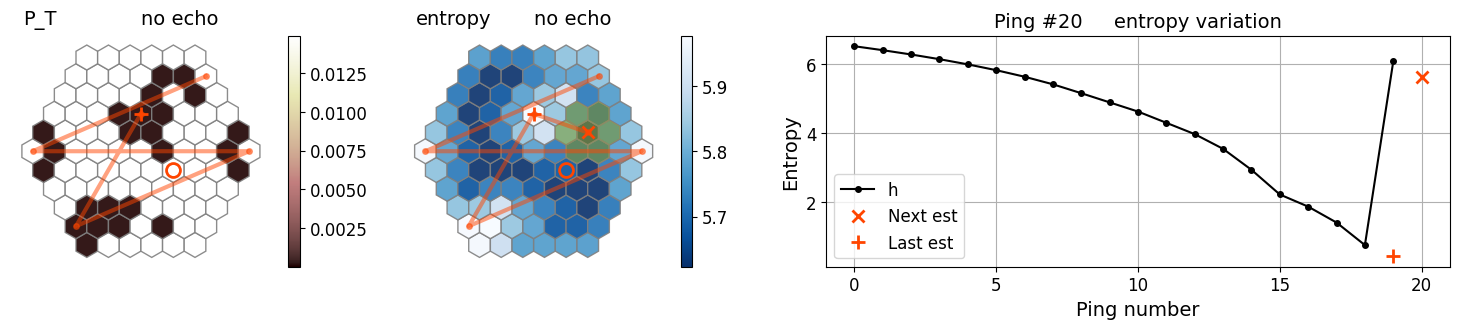

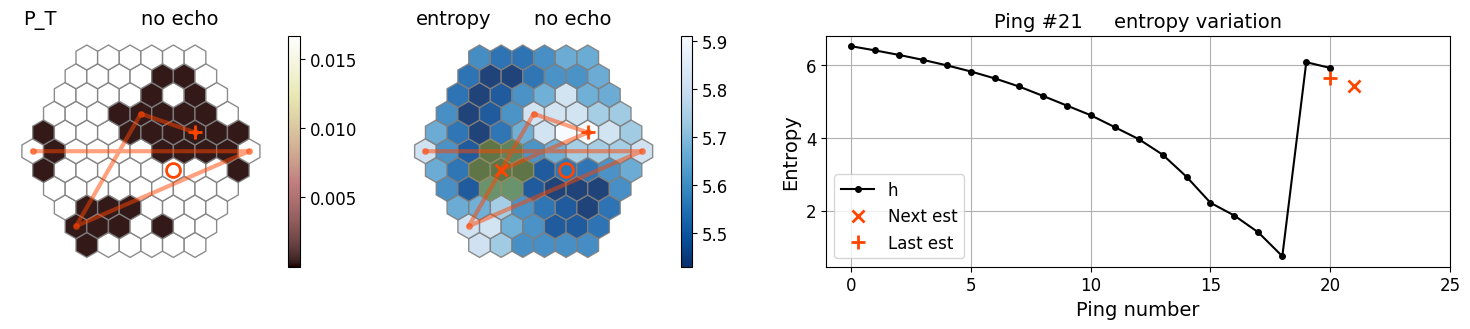

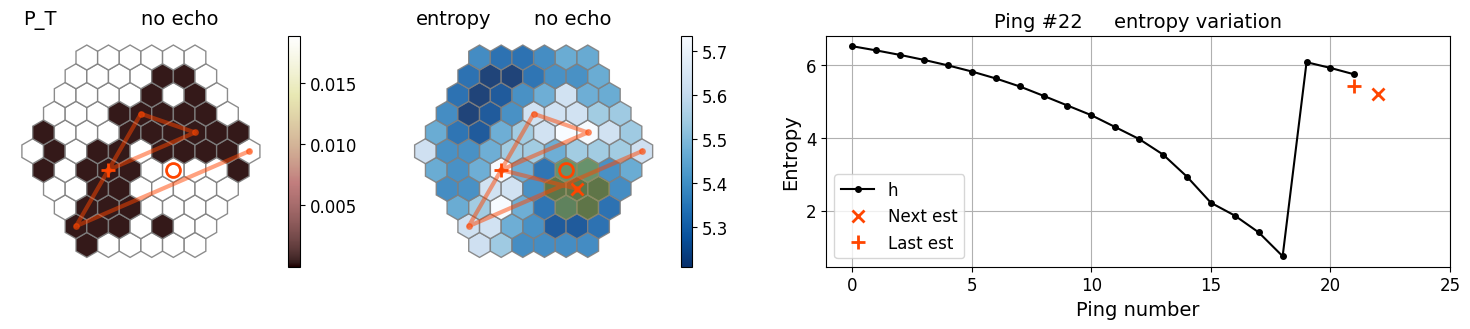

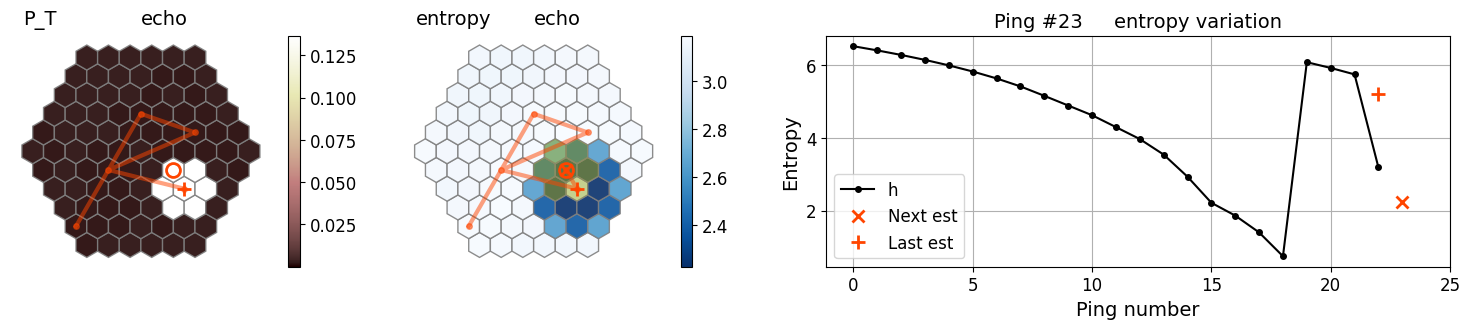

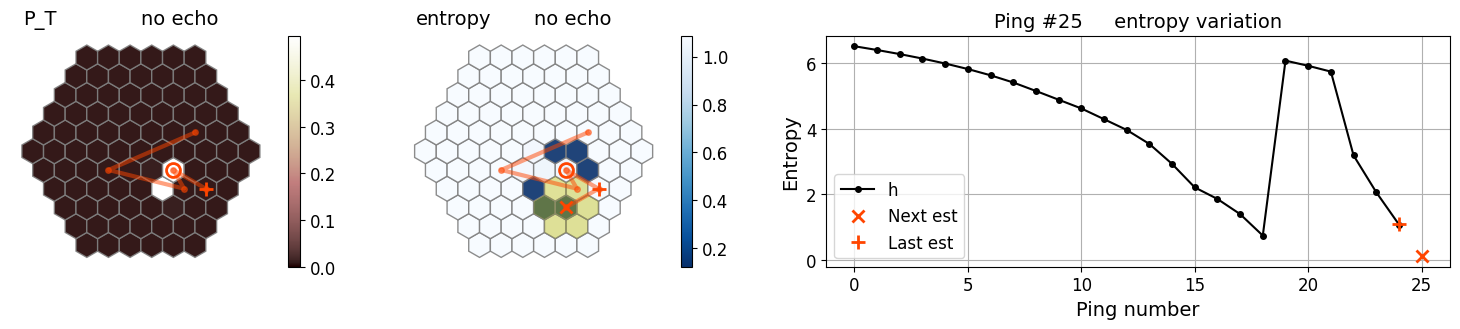

In [5]:
pings_to_plot = np.array([4, 19, 20, 21, 22, 23, 25])
idx_to_plot = pings_to_plot-1
for idx in idx_to_plot:
    utils_plot_hex.plot_step_from_nc(ds, idx)

In [6]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_loc_standalone(ax, axis_ij, sym='o', color='m', size=10):
    ax.plot(axis_ij[0], axis_ij[1],
            markersize=size,
            marker=sym,
            markerfacecolor="None",
            markeredgecolor=color,
            markeredgewidth=1.5)

In [7]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_dk_map_standalone(ax, canvas_cube, canvas_vmap,
    beam_cube, env_attrs, plot_attrs, cmap="Blues_r",
    remove_cbar=False
):
    im, cbar = hex_ops.plot_hexgrids(ax,
                                     cube_array=canvas_cube,
                                     cube_color=canvas_vmap,
                                     cmap=cmap)
    ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    ax.axis('equal')

    # Beam and beam trace
    beam_plotxy = np.array([hex_ops.get_cube_plot_xy(x).squeeze()
                            for x in beam_cube])
    beam_trace = beam_plotxy[-6:, :]    # plot last 5 beam axis loc and the next
    beam_next = beam_plotxy[-1, :]   # next beam axis loc

    ax.plot(beam_trace[:, 0], beam_trace[:, 1], marker='.',
            color=plot_attrs['symbol_color'], alpha=0.5, linewidth=2, markersize=4)
    if beam_plotxy.shape[0] > 1:  # if there was a last beam
        plot_loc_standalone(ax=ax, axis_ij=beam_plotxy[-2, :],  # plot last beam axis
                 sym='+', color=plot_attrs['symbol_color'], size=8)
    if beam_next is not None:
        plot_loc_standalone(ax=ax, axis_ij=beam_next,  # plot last beam axis
                 sym='x', color=plot_attrs['symbol_color'], size=6)

    # Target and peg locs
    if 'target_loc' in env_attrs:
        plot_loc_standalone(ax, hex_ops.get_cube_plot_xy(env_attrs['target_loc']),
                 sym='o', color=plot_attrs['symbol_color'], size=8)  # target location

    # cbar.ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    if remove_cbar:
        cbar.remove()
    else:
        cbar.ax.set_yticks([])
        pos = cbar.ax.get_position()
        cbar.ax.set_position([pos.x0 - 0.015, pos.y0, pos.width, pos.height])

In [8]:
plot_attrs = utils_plot_hex.PLOT_ATTRS
plot_attrs

{'ticklabel_fontsize': 12,
 'title_fontsize': 14,
 'axislabel_fontsize': 14,
 'legend_fontsize': 12,
 'symbol_color': 'orangered'}

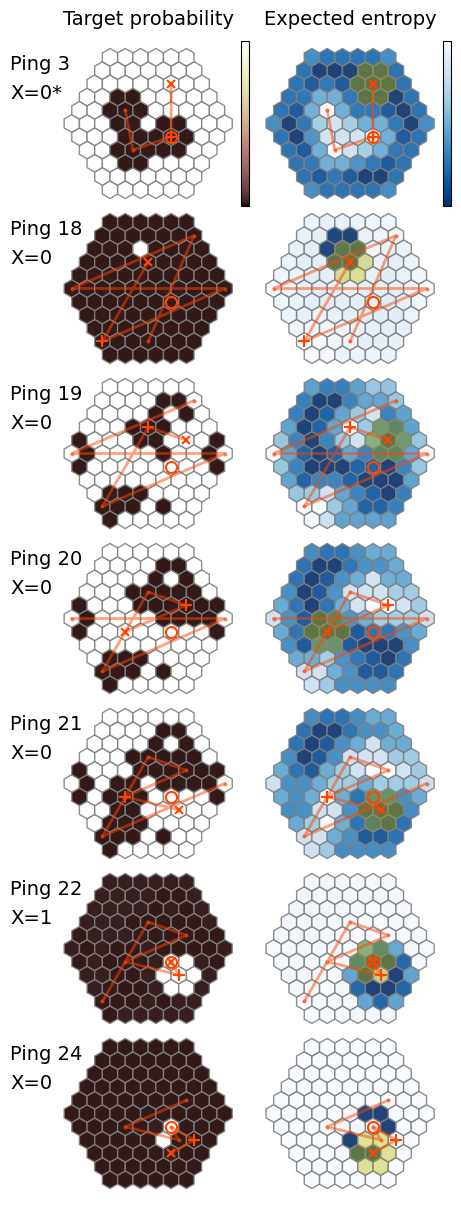

In [9]:
# Construct env_attrs for plotting
env_attrs = dict(target_loc=ds.attrs['target_loc'])

fig, ax_all = plt.subplots(7, 2, figsize=(5.5, 15))
fig.subplots_adjust(hspace=0, wspace=-0.1)

for seq, ping_num in enumerate(idx_to_plot):

    # Whether remove colorbar
    remove_cbar = True if seq > 0 else False

    # Get beam radius
    beam_r = ds["radius_all"].isel(steps=ping_num).values

    # Target probability map
    ax = ax_all[seq, 0]
    plot_dk_map_standalone(
        ax,
        canvas_cube=ds['canvas_cube'].values,
        canvas_vmap=ds['d_all'].isel(steps=ping_num).values,
        beam_cube=ds['beam_cube_all'].isel(steps=slice(0, ping_num + 1)).values,
        env_attrs=env_attrs,
        plot_attrs=plot_attrs,
        cmap="pink",
        remove_cbar=remove_cbar
    )
    ttype = ax.text(x=-0.27, y=0.83, s=f'Ping {ping_num}',
                transform=ax.transAxes,
                fontsize=14)
    if ds["echo_value_all"].isel(steps=ping_num).values == 0:
        x = "0" if ds["echo_type_all"].isel(steps=ping_num).values == 1 else "0*"  # * for miss
    else:
        x = "1" if ds["echo_type_all"].isel(steps=ping_num).values == 1 else "1*"  # * for false alarm
    ttype = ax.text(x=-0.27, y=0.65, s=f'X={x}',
                transform=ax.transAxes,
                fontsize=14)
    ax.patch.set_visible(False)
    ax.axis('off')

    # Expected entropy map
    ax = ax_all[seq, 1]
    plot_dk_map_standalone(
        ax,
        canvas_cube=ds['canvas_cube'].values,
        canvas_vmap=ds['h_est_all'].isel(steps=ping_num).sel(beam_radius=beam_r).values,
        beam_cube=ds['beam_cube_all'].isel(steps=slice(0, ping_num + 1)).values,
        env_attrs=env_attrs,
        plot_attrs=plot_attrs,
        cmap="Blues_r",
        remove_cbar=remove_cbar
    )

    # Next beam coverage
    canvas_axial = hex_ops.cube_to_axial(ds['canvas_cube'])  # the entire canvas in axial coordinate
    last_beam_cover_cube = utils_plot_hex.beam_shape_hex(cube_ctr=ds['beam_cube_all'].isel(steps=ping_num).values,
                                            canvas_axial=canvas_axial,
                                            beam_radius=beam_r)
    hex_ops.plot_hexgrids(ax, cube_array=last_beam_cover_cube,
                            cube_color='y', gridalpha=0.4)

    ax.patch.set_visible(False)
    ax.axis('off')

# Add title
ax_all[0, 0].set_title("Target probability", fontsize=14, pad=12)
ax_all[0, 1].set_title("Expected entropy", fontsize=14, pad=12)

plt.show()


fig.savefig(path_fig / "fig_infotaxis_miss_A.png", dpi=300, bbox_inches="tight")

In [10]:
p_max = ds["d_all"].max(dim="canvas").values
p_max

array([0.01098901, 0.01190377, 0.01298465, 0.01428143, 0.01586596,
       0.01784598, 0.02039067, 0.02378175, 0.02852574, 0.0344103 ,
       0.04155228, 0.05243544, 0.06633906, 0.0902928 , 0.1413211 ,
       0.24527315, 0.32519393, 0.48237193, 0.93450074, 0.01492047,
       0.01665861, 0.0188551 , 0.13658204, 0.24812937, 0.495527  ,
       0.98914808, 0.99891649, 0.99993662, 0.99999256, 0.99999956,
       0.99999995, 1.        ])

In [11]:
pmax_diff_threshold=1e-5
criteria = {
    "pmax_repeat_N": 3,
    "max_ping_num": 500,
    "pmax_diff_threshold": pmax_diff_threshold,
}    
for p in range(len(p_max)):
    if p - criteria["pmax_repeat_N"] < 0:
        continue
    p_max_diff = np.diff(p_max[p-criteria["pmax_repeat_N"]+1:p+1])
    print(p_max_diff)
    if len(p_max_diff) > 1 and np.all(abs(p_max_diff) < criteria["pmax_diff_threshold"]):
        p_converged = p
        break

[0.00108088 0.00129678]
[0.00129678 0.00158453]
[0.00158453 0.00198002]
[0.00198002 0.00254469]
[0.00254469 0.00339108]
[0.00339108 0.00474399]
[0.00474399 0.00588456]
[0.00588456 0.00714198]
[0.00714198 0.01088316]
[0.01088316 0.01390362]
[0.01390362 0.02395374]
[0.02395374 0.0510283 ]
[0.0510283  0.10395205]
[0.10395205 0.07992078]
[0.07992078 0.157178  ]
[0.157178   0.45212881]
[ 0.45212881 -0.91958027]
[-0.91958027  0.00173814]
[0.00173814 0.0021965 ]
[0.0021965  0.11772694]
[0.11772694 0.11154733]
[0.11154733 0.24739763]
[0.24739763 0.49362108]
[0.49362108 0.00976841]
[0.00976841 0.00102013]
[1.02013452e-03 5.59320409e-05]
[5.59320409e-05 7.00354408e-06]
[7.00354408e-06 3.87453657e-07]


In [12]:
p_converged

30

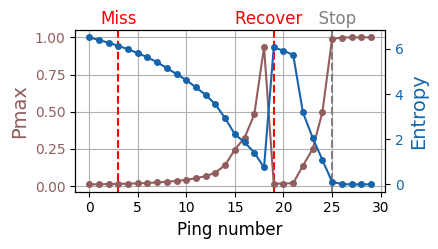

In [13]:
# Get data to plot
idx_miss = 3
idx_recover = 19
h_actual_all = ds['h_actual_all'].values
p_max_all = ds['d_all'].max(dim="canvas").values

# Set up colors
cmap_tmp = matplotlib.colormaps["pink"]
colors_tmp = [cmap_tmp(c / 5) for c in range(5)]
colors = [colors_tmp[1]]
cmap_tmp = matplotlib.colormaps["Blues_r"]
colors_tmp = [cmap_tmp(c / 5) for c in range(5)]
colors.append(colors_tmp[1])


# First y-axis for pmax
fig, ax = plt.subplots(1, 1, figsize=(4, 2.1))
pingnum = len(h_actual_all[:p_converged])   # all ping number
ax.axvline(idx_miss, color="r", ls="--") # miss
ax.axvline(idx_recover, color="r", ls="--") # recover
ax.axvline(ping_cross, color="grey", ls="--")
ax.plot(np.arange(pingnum), p_max_all[:p_converged],  # pmax
        color=colors[0], marker='.', markersize=8, label='Pmax')

ax.set_xticks(np.arange(0, pingnum + 5, 5))
ax.set_xlabel('Ping number', fontsize=12)
ax.set_ylabel('Pmax', fontsize=14, color=colors[0])
ax.tick_params(axis='y', labelcolor=colors[0], labelsize=10)
ax.grid()

# Create second y-axis for pmax
ax2 = ax.twinx()
ax2.plot(np.arange(pingnum), h_actual_all[:p_converged],  # actual entropy
        color=colors[1], marker='.', markersize=8, label='Entropy')
ax2.set_ylabel('Entropy', fontsize=14, color=colors[1])
ax2.tick_params(axis='y', labelcolor=colors[1], labelsize=10)

# ax.set_title('Entropy and max target probability variation', fontsize=12)

ax2.text(x=idx_miss, y=7.1, s='Miss', color='red', fontsize=12, ha="center")
ax2.text(x=idx_recover, y=7.1, s='Recover  ', color='red', fontsize=12, ha="center")
ax2.text(x=ping_cross, y=7.1, s='  Stop', color='grey', fontsize=12, ha="center")

ax.set_xticks(np.arange(0, 31, 5))
ax.set_xticklabels(np.arange(0, 31, 5))

plt.show()

fig.savefig(path_fig / "fig_infotaxis_miss_B.png", dpi=300, bbox_inches="tight")